# Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering

Name: Rabi Gurung  
Course: Advanced Big Data and Data Mining, MSCS-634-B01  
Assignment: Lab 5

## Overview

This notebook uses the Wine dataset from `sklearn.datasets` to compare Agglomerative Hierarchical Clustering and DBSCAN. The work includes data exploration, standardization, cluster visualizations, a dendrogram, clustering metrics, and a short comparison of the two methods.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True


In [2]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target
print('Shape:', X.shape)
display(X.head())


Shape: (178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [4]:
display(X.describe().T)


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print('Explained variance by first two PCA components:', pca.explained_variance_ratio_)


Explained variance by first two PCA components: [0.36198848 0.1920749 ]


## Hierarchical Clustering

I tested different values of `n_clusters` to see how the number of groups changes the clustering quality. The PCA plot is used only for visualization, while clustering is done on all standardized features.

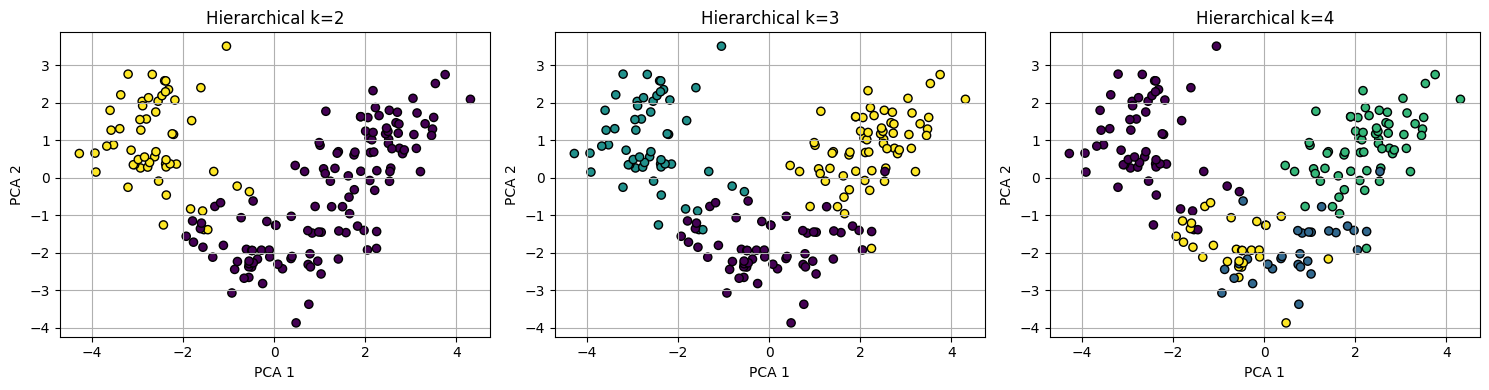

,model,silhouette,homogeneity,completeness
0,Hierarchical k=2,0.267013,0.444094,0.774489
1,Hierarchical k=3,0.277444,0.790429,0.782541
2,Hierarchical k=4,0.225837,0.790429,0.649028


In [6]:
hier_results = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [2, 3, 4]):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    hom = homogeneity_score(y, labels)
    comp = completeness_score(y, labels)
    hier_results.append({'model': f'Hierarchical k={k}', 'silhouette': sil, 'homogeneity': hom, 'completeness': comp})
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', edgecolor='k', s=35)
    ax.set_title(f'Hierarchical k={k}')
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
plt.tight_layout()
plt.show()
pd.DataFrame(hier_results)


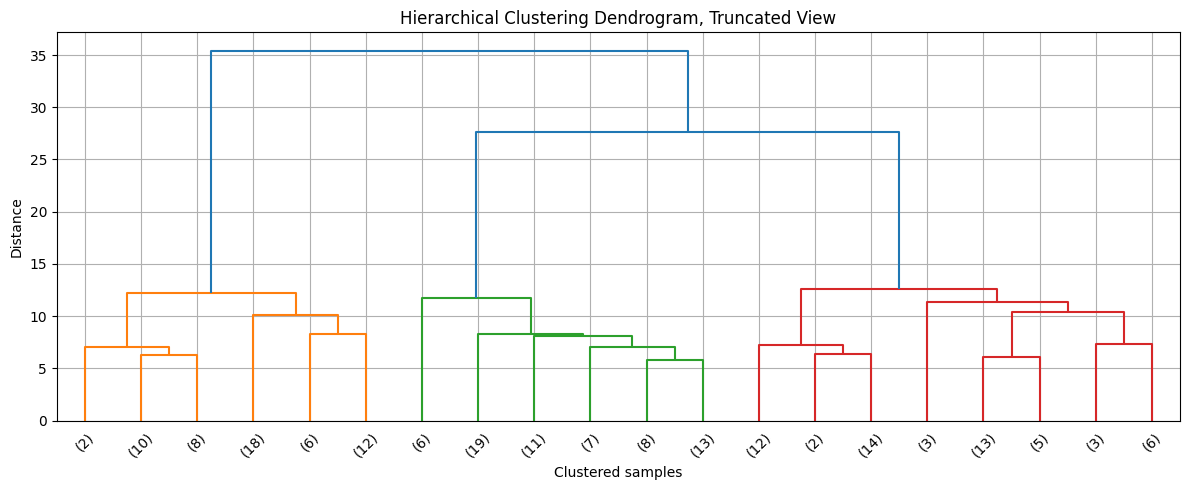

In [7]:
linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=45, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram, Truncated View')
plt.xlabel('Clustered samples')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


The hierarchical results show that three clusters are a good fit for this dataset. This makes sense because the Wine dataset has three known classes. The dendrogram also shows large vertical jumps near the top, which supports using a small number of larger clusters rather than many small groups.

## DBSCAN Clustering

DBSCAN depends strongly on `eps` and `min_samples`. I tested several settings to show how the algorithm can create clusters and noise points.

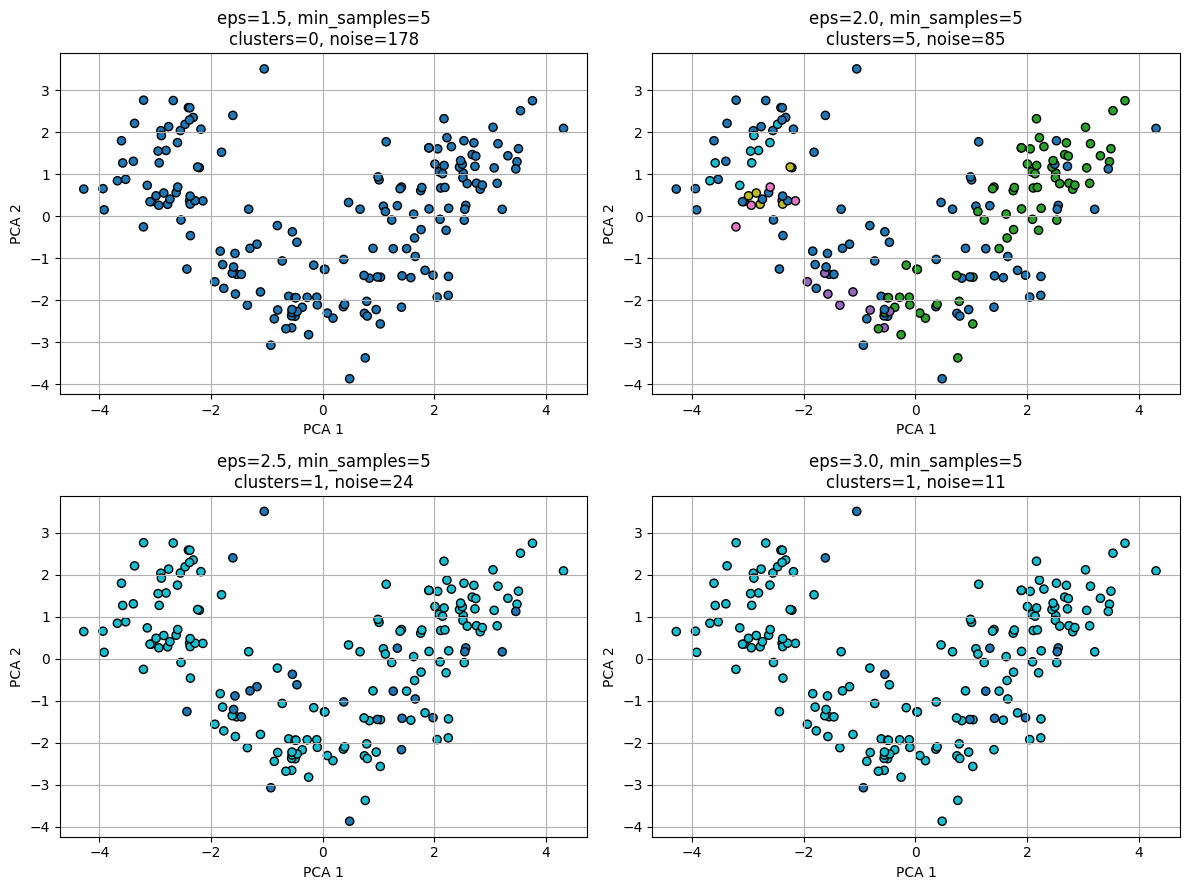

,model,clusters,noise,silhouette,homogeneity,completeness
0,"DBSCAN eps=1.5, min=5",0,178,NaN,0.000000,1.000000
1,"DBSCAN eps=2.0, min=5",5,85,-0.032906,0.362354,0.324734
2,"DBSCAN eps=2.5, min=5",1,24,NaN,0.057588,0.158148
3,"DBSCAN eps=3.0, min=5",1,11,NaN,0.030877,0.144610


In [8]:
dbscan_settings = [(1.5, 5), (2.0, 5), (2.5, 5), (3.0, 5)]
db_results = []
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (eps, min_samples) in zip(axes.ravel(), dbscan_settings):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X_scaled)
    cluster_count = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = int(np.sum(labels == -1))
    if cluster_count > 1:
        sil = silhouette_score(X_scaled, labels)
    else:
        sil = np.nan
    hom = homogeneity_score(y, labels)
    comp = completeness_score(y, labels)
    db_results.append({'model': f'DBSCAN eps={eps}, min={min_samples}', 'clusters': cluster_count, 'noise': noise_count, 'silhouette': sil, 'homogeneity': hom, 'completeness': comp})
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', edgecolor='k', s=35)
    ax.set_title(f'eps={eps}, min_samples={min_samples}\nclusters={cluster_count}, noise={noise_count}')
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
plt.tight_layout()
plt.show()
pd.DataFrame(db_results)


DBSCAN was more sensitive to parameter choices than hierarchical clustering. With small `eps`, many points were treated as noise. As `eps` increased, more points joined clusters, but the method did not match the three known wine classes as clearly as hierarchical clustering. This shows that DBSCAN can be useful for irregular cluster shapes and noise detection, but it needs careful parameter tuning.

In [9]:
summary = pd.concat([pd.DataFrame(hier_results), pd.DataFrame(db_results)], ignore_index=True)
display(summary)


,model,silhouette,homogeneity,completeness,clusters,noise
0,Hierarchical k=2,0.267013,0.444094,0.774489,NaN,NaN
1,Hierarchical k=3,0.277444,0.790429,0.782541,NaN,NaN
2,Hierarchical k=4,0.225837,0.790429,0.649028,NaN,NaN
3,"DBSCAN eps=1.5, min=5",NaN,0.000000,1.000000,0.0,178.0
4,"DBSCAN eps=2.0, min=5",-0.032906,0.362354,0.324734,5.0,85.0
5,"DBSCAN eps=2.5, min=5",NaN,0.057588,0.158148,1.0,24.0
6,"DBSCAN eps=3.0, min=5",NaN,0.030877,0.144610,1.0,11.0


## Analysis and Insights

Hierarchical clustering gave the clearest result for the Wine dataset, especially with `n_clusters=3`. It produced useful cluster separation and matched the known class structure better than most DBSCAN settings. DBSCAN was useful for showing noise points, but it was harder to tune because the standardized Wine data does not form obvious density-based clusters. The main decision in hierarchical clustering was the number of clusters. The main decisions in DBSCAN were `eps` and `min_samples`, and small changes in `eps` changed the number of noise points a lot.

One challenge was choosing DBSCAN parameters fairly. I used several values of `eps` so the comparison would show the effect of parameter changes instead of depending on one arbitrary setting.